← [Del modelo al robot](12-del-modelo-al-robot.ipynb) · [Índice](00-indice.ipynb) · Siguiente: [Conexiones físicas](14-conexiones-fisicas.ipynb) →

# 13 · Conceptos clave

Glosario de referencia. A diferencia del resto de la serie, este documento no se
lee de corrido: se consulta. Cada término trae su definición, cómo aparece en
Reci y dónde se explica a fondo.

---



## Parte A — Conceptos de la materia

### Sistemas expertos

| Término | Qué es | En Reci |
| --- | --- | --- |
| **Sistema experto** | Programa que resuelve problemas aplicando conocimiento humano escrito como reglas | 193 reglas para clasificar residuos |
| **Base de conocimiento** | Lo que el sistema sabe siempre, independiente del caso | `knowledge_base.py` |
| **Memoria de trabajo** | Los hechos del caso concreto que se está resolviendo | `working_memory.py` |
| **Motor de inferencia** | El mecanismo que aplica el conocimiento a los hechos | `inference_engine.py` |
| **Regla de producción** | Estructura `SI condición ENTONCES conclusión` | `Rule("R01", {...}, "VIDRIO", 0.98, "...")` |
| **Antecedente** | La parte `SI` de una regla | Diccionario de atributos que deben coincidir |
| **Consecuente** | La parte `ENTONCES` | `VIDRIO`, `PLASTICO`, `ORGANICO`, `LATA` |
| **Hecho** | Un dato conocido sobre el objeto actual | `transparencia = alta` |
| **Disparar una regla** | Que su antecedente se cumpla y aporte su conclusión | Suma su CF a una categoría |

### Razonamiento

| Término | Qué es | En Reci |
| --- | --- | --- |
| **Encadenamiento hacia adelante** | Partir de los hechos y ver a qué conclusiones llevan | El modo principal |
| **Encadenamiento hacia atrás** | Partir de una hipótesis y verificar si los hechos la sostienen | Verificación cruzada del anterior |
| **Meta-regla** | Regla sobre *cómo razonar*, no sobre el objeto | `meta_rules.py` |
| **Factor de certeza (CF)** | Grado de confianza de −1 a +1, con aritmética propia | Fórmula MYCIN |
| **MYCIN** | Sistema experto médico de Stanford (años 70) | De ahí viene la aritmética de CF |
| **Explicabilidad** | Poder justificar por qué se llegó a una conclusión | Campo `rule_applied` |
| **Abstención** | Negarse a decidir por falta de evidencia | `desconocido` |

📖 A fondo: [03](03-sistema-experto-reglas.ipynb), [04](04-factor-de-certeza.ipynb), [05](05-motor-de-inferencia.ipynb)

### Aprendizaje automático

| Término | Qué es | En Reci |
| --- | --- | --- |
| **Red neuronal** | Modelo con parámetros ajustados a partir de ejemplos | MobileNetV2, ≈2,36 M parámetros |
| **CNN** | Red convolucional, especializada en imágenes | La arquitectura del modelo local |
| **Convolución** | Ventana pequeña que recorre la imagen buscando un patrón | Da invariancia a la posición |
| **Parámetro / peso** | Cada número interno que el entrenamiento ajusta | Ninguno significa nada por sí solo |
| **Clasificación binaria** | Elegir entre exactamente dos clases | `plastico` o `vidrio` — nada más |
| **Softmax** | Convierte las salidas en valores que suman 1,0 | Por eso no puede abstenerse |
| **Aprendizaje supervisado** | Aprender de ejemplos ya etiquetados | 18.030 fotos con su material anotado |

📖 A fondo: [06](06-redes-neuronales.ipynb)

---



## Parte B — Conceptos del modelo

### Entrenamiento

| Término | Qué es | Valor en Reci |
| --- | --- | --- |
| **Transfer learning** | Partir de una red ya entrenada en otra tarea | Pesos de ImageNet |
| **ImageNet** | Dataset de ~1,2 M fotos en 1.000 categorías | El punto de partida |
| **Backbone** | El cuerpo de la red que extrae características | MobileNetV2 sin su capa final |
| **Cabeza** | Las capas finales, específicas del problema | `GlobalAveragePooling → Dropout → Dense(2)` |
| **Congelar** | Impedir que unas capas se modifiquen | Fase 1 del entrenamiento |
| **Ajuste fino** *(fine-tuning)* | Descongelar y reentrenar con pasos pequeños | Fase 2, tasa `1e-5` |
| **Época** *(epoch)* | Una pasada completa por el dataset | Las corridas pararon entre 12 y 27 |
| **Lote** *(batch)* | Fotos procesadas antes de cada ajuste | 32 por defecto |
| **Tasa de aprendizaje** | Tamaño del paso al corregir | `1e-3` fase 1, `1e-5` fase 2 |
| **Aumentos** *(augmentation)* | Variar las fotos de entrenamiento a propósito | Degradación a QVGA y compresión JPEG |
| **Semilla** | Número que fija el azar para poder repetir | 3 semillas por arquitectura |
| **Parada temprana** | Detener cuando deja de mejorar | Sobre `val_macro_f1` |

### Datos

| Término | Qué es | Valor en Reci |
| --- | --- | --- |
| **Entrenamiento** | Partición para ajustar los parámetros | 17.630 imágenes |
| **Validación** | Partición para elegir entre alternativas | 199 imágenes |
| **Prueba** | Partición para estimar el rendimiento real | 200 imágenes, se abre **una vez** |
| **Fuga de datos** *(leakage)* | Información de prueba filtrada al entrenamiento | Se evita partiendo por sesión |
| **Sesión** | Una ráfaga de capturas relacionadas | Unidad indivisible de la partición |
| **Sobreajuste** *(overfitting)* | Memorizar en vez de generalizar | Riesgo con pocos datos |
| **Cambio de dominio** | Cambia la cámara, la luz o el fondo | 98,43 % → 71,60 % |
| **Atajos** *(shortcut learning)* | Aprender una pista casual en vez del concepto | La clase débil se invirtió al cambiar de cámara |

### Evaluación

| Término | Qué mide | Por qué importa |
| --- | --- | --- |
| **Exactitud** *(accuracy)* | Fracción de aciertos | **Engaña**: esconde una clase mala en el promedio |
| **Matriz de confusión** | Qué se confunde con qué | Muestra el tipo de error, no solo la cantidad |
| **Precisión** | De lo que llamé X, ¿cuánto era X? | Mide los falsos positivos |
| **Recall** | De todo el X que había, ¿cuánto encontré? | Mide los falsos negativos |
| **F1** | Media armónica de precisión y recall | Alta solo si **ambas** lo son |
| **Macro-F1** | F1 promediado dando igual peso a cada clase | **La métrica principal del proyecto** |
| **Errores con confianza alta** | Fallos con confianza ≥ 0,90 | Mide si se puede confiar en la confianza |
| **Calibración** | Si la confianza declarada corresponde al acierto real | El modelo original no estaba calibrado |

### Despliegue

| Término | Qué es | En Reci |
| --- | --- | --- |
| **TensorFlow Lite** | Formato ligero para ejecutar, no entrenar | `model.tflite`, ~8,5 MB |
| **Cuantización** | Pasar los parámetros de float32 a int8 | ~4× menos espacio |
| **Regresión por cuantización** | Cuánta exactitud se pierde al cuantizar | Criterio 4 de la propuesta |
| **Activación** | Función entre capas | ReLU6 (acotada) cuantiza bien; hard-swish, mal |
| **Latencia** | Tiempo de una predicción | p50 y p95, medidas por corrida |
| **Modo sombra** | Registrar predicciones sin dejar que decidan | Paso previo obligatorio al despliegue |

📖 A fondo: [07](07-transfer-learning-y-mobilenet.ipynb), [08](08-cambio-de-dominio.ipynb), [11](11-como-se-mide.ipynb), [12](12-del-modelo-al-robot.ipynb)

---



## Parte C — Los cinco malentendidos frecuentes

### 1. «El modelo tiene 98 % de precisión»

**No.** Tenía 98,43 % en el dataset con el que se entrenó. En capturas reales de
la ESP32-CAM baja a 71,60 %. Nunca presentar la primera cifra como la precisión
esperada del robot.

### 2. «Si la confianza es alta, probablemente acertó»

**No en este modelo.** De 25 errores de vidrio, 17 tenían confianza ≥ 0,90 y dos
exactamente 1,0000. La confianza de la softmax mide el reparto interno, no la
probabilidad de acertar.

### 3. «Un CF de 0,95 y una confianza de 0,95 son comparables»

**No.** El CF viene del juicio de un experto y no suma nada en particular entre
hipótesis; la softmax siempre suma 1,0. Por eso el sistema **vota** en vez de
promediar.

### 4. «Con más fotos por residuo se corrigen los errores»

**Solo el ruido momentáneo.** En 32 ráfagas de 3 fotos, el modelo dio el mismo
resultado en 30. Es estable en el acierto **y en el error**: tres fotos no
rescatan un fallo sistemático de dominio.

### 5. «Ganó en validación, entonces es el que se despliega»

**No necesariamente.** MobileNetV3-Large gana en validación (0,9363) pero pierde
0,350 de macro-F1 al cuantizarse a int8. Hay que medir el artefacto que se
despliega, no el modelo que se entrenó.

---



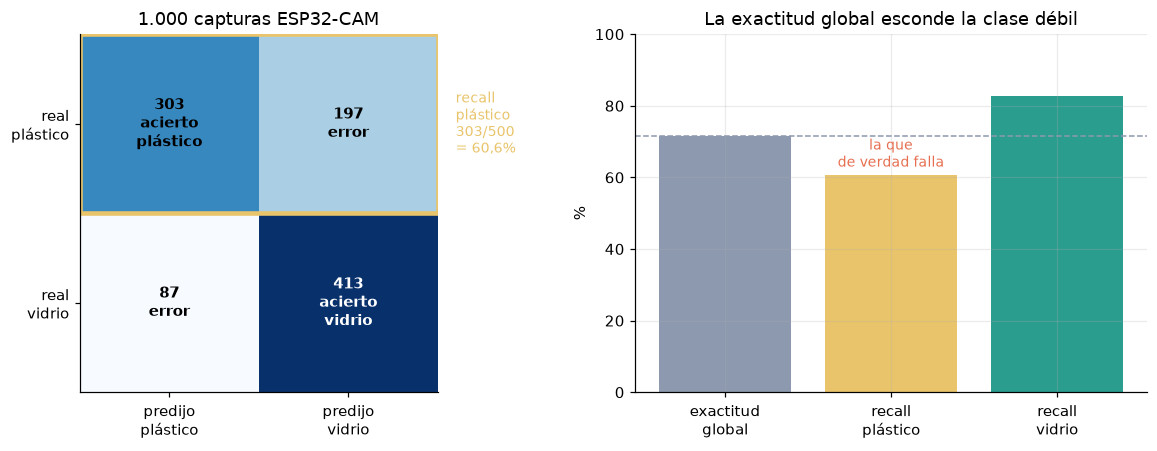

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

VIDRIO, PLASTICO, GRIS, ALERTA = "#2a9d8f", "#e9c46a", "#8d99ae", "#e76f51"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

# De dónde salen precisión, recall y F1 en una matriz de confusión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

m = np.array([[303, 197], [87, 413]])   # ESP32-CAM, 1.000 capturas balanceadas
ax1.imshow(m, cmap="Blues"); ax1.grid(False)
ax1.set_xticks([0, 1]); ax1.set_xticklabels(["predijo\nplástico", "predijo\nvidrio"])
ax1.set_yticks([0, 1]); ax1.set_yticklabels(["real\nplástico", "real\nvidrio"])
ax1.set_title("1.000 capturas ESP32-CAM")
etiquetas = [["acierto\nplástico", "error"], ["error", "acierto\nvidrio"]]
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f"{m[i, j]}\n{etiquetas[i][j]}", ha="center", va="center",
                 color="white" if m[i, j] > 350 else "black", fontsize=10, weight="bold")
ax1.add_patch(plt.Rectangle((-0.5, -0.5), 2, 1, fill=False, ec=PLASTICO, lw=3))
ax1.text(1.6, 0, "recall\nplástico\n303/500\n= 60,6%", va="center", fontsize=9, color=PLASTICO)

# Exactitud global frente a recall por clase
ax2.bar(["exactitud\nglobal", "recall\nplástico", "recall\nvidrio"],
        [71.6, 60.6, 82.6], color=[GRIS, PLASTICO, VIDRIO])
ax2.axhline(71.6, ls="--", color=GRIS, lw=1)
ax2.set(ylabel="%", ylim=(0, 100),
        title="La exactitud global esconde la clase débil")
ax2.text(1, 63, "la que\nde verdad falla", ha="center", fontsize=9, color=ALERTA)

plt.tight_layout(); plt.show()

## Cómo se traducen entre sí las dos familias

Los dos caminos de Reci hacen lo mismo con vocabularios distintos. Esta
equivalencia ayuda a no confundirlos:

| Función | Sistema experto | Red neuronal |
| --- | --- | --- |
| Dónde vive el conocimiento | Base de conocimiento (reglas) | Parámetros (pesos) |
| De dónde salió | Lo escribió un experto | Se ajustó con ejemplos |
| Datos del caso actual | Memoria de trabajo | El tensor de entrada |
| Producir un resultado | Disparar reglas y acumular CF | Propagar hacia adelante |
| Medida de confianza | Factor de certeza | Probabilidad softmax |
| Corregir un error | Editar o añadir una regla | Reentrenar con más datos |
| Justificar el resultado | Reporte de reglas disparadas | No hay equivalente |

---

← [Del modelo al robot](12-del-modelo-al-robot.ipynb) · [Índice](00-indice.ipynb) · Siguiente: [Conexiones físicas](14-conexiones-fisicas.ipynb) →
